<a href="https://colab.research.google.com/github/ShuhaievaPolina/MNIST-Classification/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision as tv
from torch.utils.data import DataLoader, random_split
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.gridspec import GridSpec

In [2]:
train_transform = tv.transforms.Compose([

    tv.transforms.RandomRotation(degrees=10),
    tv.transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.1307,), (0.3081,))
])


test_transform = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.1307,), (0.3081,))
])

In [3]:
full_train_dataset = tv.datasets.MNIST('./datasets',train=True, download=True, transform=train_transform)
test_dataset = tv.datasets.MNIST('./datasets',train=False, download=True, transform=test_transform)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

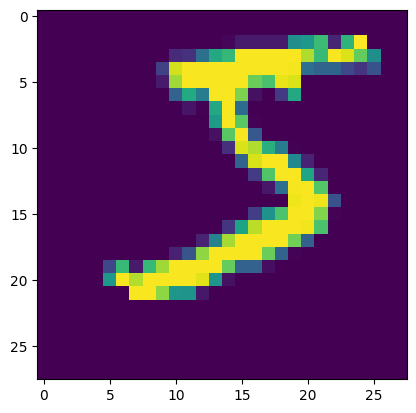

In [5]:
full_train_dataset[0][0].numpy()[0].shape
plt.imshow(full_train_dataset[0][0].numpy()[0])

In [6]:
train_size = 50000
val_size = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size]
)

batch_size = 64

# dataloader = torch.utils.data.DataLoader(
#    dataset, batch_size=batch_size, shuffle=True,
#    num_workers=1, drop_last=True
# )

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False
)

test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

print(f'TRAIN DATASET: {len(train_dataset)}')
print(f'VALIDATION DATASET: {len(val_dataset)}')
print(f'TEST DATASET: {len(test_dataset)}')

TRAIN DATASET: 50000
VALIDATION DATASET: 10000
TEST DATASET: 10000


In [7]:
for img, lable in train_loader:
  print(img.shape)
  print(lable.shape)
  break

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [8]:
class Neural_numbers(nn.Module):
  def __init__(self):
    super().__init__()

    self.flat = nn.Flatten()
    self.linear1 = nn.Linear(28*28, 128)
    self.act = nn.ReLU()
    self.linear2 = nn.Linear(128,128)
    self.linear3 = nn.Linear(128,10)


  def forward(self, x):
    out = self.flat(x)
    out = self.linear1(out)
    out = self.act(out)
    out = self.linear2(out)
    out = self.act(out)
    out = self.linear3(out)

    return out


In [9]:
def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [10]:
model = Neural_numbers().to(device)

In [11]:
count_parameters(model)

118282

In [12]:
loss_fn = nn.CrossEntropyLoss()

In [13]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

In [14]:
def accuracy(pred, label):
  correct = pred.argmax(dim=1) == label
  return correct.float().mean().item()

In [15]:
def show_full_dashboard(train_loss, val_loss, train_acc, val_acc, true_labels, predicted_labels, classes):
  fig = plt.figure(figsize=(15, 12))
  gs =GridSpec(nrows=2, ncols=4, figure=fig, hspace=0.4)

  ax_loss = fig.add_subplot(gs[0, 0:2])
  ax_loss.plot(train_loss, label='TRAIN LOSS', color='blue', marker='o')
  ax_loss.plot(val_loss, label='VALIDATION LOSS', color='red', marker='o')
  ax_loss.set_title('LOSS FUNCTION')
  ax_loss.set_xlabel('Epoch')
  ax_loss.grid(True)
  ax_loss.legend()

  ax_acc = fig.add_subplot(gs[0, 2:4])
  ax_acc.plot(train_acc, label='TRAIN ACCURACY', color='blue', marker='o')
  ax_acc.plot(val_acc, label='VALIDATION ACCURACY', color='red', marker='o')
  ax_acc.set_title('ACCURACY FUNCTION')
  ax_acc.set_xlabel('Epoch')
  ax_acc.grid(True)
  ax_acc.legend()

  ax_cm = fig.add_subplot(gs[1, 1:3])
  cm = confusion_matrix(true_labels, predicted_labels)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

  disp.plot(cmap='Blues', ax=ax_cm, values_format='d')
  ax_cm.set_title('CONFUSION MATRIX')

  plt.show()


100%|██████████| 157/157 [00:03<00:00, 40.26it/s]


EPOCH: 1/7 
EPOCH TRAIN LOSS: 0.5718313797622385 | EPOCH TRAIN ACCURACY: 82.00327685421995 
EPOCH VALIDATION LOSS: 0.30388884018560886 | EPOCH VALIDATION ACCURACY: 90.91361464968153


100%|██████████| 157/157 [00:04<00:00, 39.15it/s]


EPOCH: 2/7 
EPOCH TRAIN LOSS: 0.2537886185804977 | EPOCH TRAIN ACCURACY: 92.08959398976982 
EPOCH VALIDATION LOSS: 0.23478290656949305 | EPOCH VALIDATION ACCURACY: 92.62539808917198


100%|██████████| 157/157 [00:04<00:00, 33.08it/s]


...

EPOCH: 5/7 
EPOCH TRAIN LOSS: 0.16851163596210197 | EPOCH TRAIN ACCURACY: 94.80898337595907 
EPOCH VALIDATION LOSS: 0.15854657458580412 | EPOCH VALIDATION ACCURACY: 95.01393312101911


100%|██████████| 157/157 [00:03<00:00, 40.06it/s]


EPOCH: 6/7 
EPOCH TRAIN LOSS: 0.15171957608607725 | EPOCH TRAIN ACCURACY: 95.2565537084399 
EPOCH VALIDATION LOSS: 0.1424054144674046 | EPOCH VALIDATION ACCURACY: 95.57125796178345


100%|██████████| 157/157 [00:04<00:00, 32.23it/s]


EPOCH: 7/7 
EPOCH TRAIN LOSS: 0.14312553036210063 | EPOCH TRAIN ACCURACY: 95.49032928388746 
EPOCH VALIDATION LOSS: 0.14705825433324857 | EPOCH VALIDATION ACCURACY: 95.23288216560509


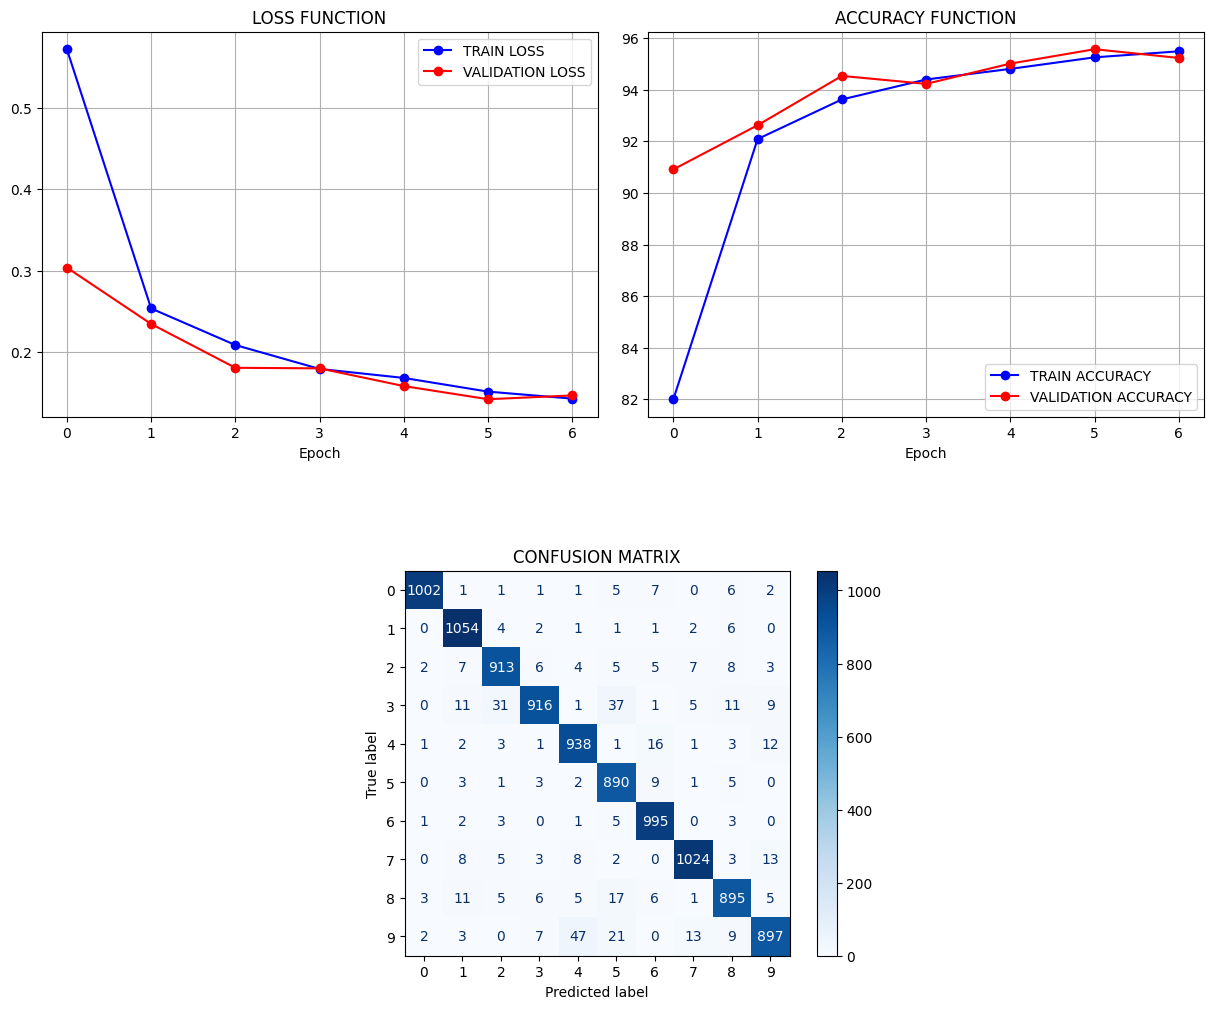

In [16]:
train_loss=[]
val_loss=[]
train_acc=[]
val_acc=[]

epochs = 7

for epoch in range(epochs):
  model.train()

  loss_total = 0
  acc_total = 0

  for img, label in (pbar := tqdm(train_loader)):

    img, label = img.to(device), label.to(device)

    optimizer.zero_grad()

    # label = F.one_hot(label, 10).float()
    pred = model(img)

    loss = loss_fn(pred, label)

    loss.backward()
    loss_item = loss.item()
    loss_total += loss_item

    optimizer.step()

    acc_current = accuracy(pred, label)
    acc_total += acc_current

    pbar.set_description(f'loss:{loss_item:.5f}\taccuracy: {acc_current:.3f}')

  model.eval()
  loss_val = 0
  acc_val = 0

  all_preds = []
  all_labels = []

  with torch.no_grad():
    for img, label in tqdm(val_loader):

      img, label = img.to(device), label.to(device)

      pred = model(img)
      loss = loss_fn(pred, label)

      loss_val += loss.item()

      acc_current = accuracy(pred, label)
      acc_val += acc_current

      if epoch == epochs-1:
        pred_classes = pred.argmax(dim=1)
        all_preds.extend(pred_classes.cpu().numpy())
        all_labels.extend(label.cpu().numpy())


  train_loss.append(loss_total/len(train_loader))
  val_loss.append(loss_val/len(val_loader))
  train_acc.append(100*acc_total/len(train_loader))
  val_acc.append(100*acc_val/len(val_loader))

  print(
      f'EPOCH: {epoch+1}/{epochs}',
      f'\nEPOCH TRAIN LOSS: {loss_total/len(train_loader)}',
      f'| EPOCH TRAIN ACCURACY: {100*acc_total/len(train_loader)}',
      f'\nEPOCH VALIDATION LOSS: {loss_val/len(val_loader)}',
      f'| EPOCH VALIDATION ACCURACY: {100*acc_val/len(val_loader)}'
  )

mnist_classes = [str(i) for i in range(10)]
show_full_dashboard(train_loss, val_loss, train_acc, val_acc, all_labels, all_preds, mnist_classes)

In [17]:
def show_img(samples, title, num = 30):
  fig,axes = plt.subplots(num//5, 5, figsize=(15,12))
  fig.suptitle(title, fontsize=16)

  for ax, (img, label, pred) in zip(axes.flatten(), samples):
    img_numpy = img.cpu().squeeze().numpy()

    ax.imshow(img_numpy)
    ax.set_title(f"GT:{label}| Pred: {pred}")
    ax.axis("off")
  plt.show()

In [1]:
model.eval()

test_acc = 0
test_loss = 0

result = []
num_samples_to_save = 30

with torch.no_grad():
  for img, label in tqdm(test_loader):

    img, label = img.to(device), label.to(device)

    pred = model(img)
    pred_label = pred.argmax(dim=1)

    for i in range(len(label)):
      if len(result)<num_samples_to_save and pred_label[i]!=label[i]:
      # if len(result)<num_samples_to_save:
        img_res = img[i].cpu()
        label_res = label[i].item()
        pred_label_res = pred_label[i].item()

        result.append((img_res, label_res, pred_label_res))

    loss = loss_fn(pred, label)
    test_loss += loss.item()

    acc_current = accuracy(pred, label)
    test_acc += acc_current
print(
    f'\nTEST ACCURACY: {100*test_acc/len(test_loader)}%',
    f'\nTEST LOSS: {test_loss/len(test_loader)}'
)

title = "RESULTS"
show_img(result, title)

NameError: name 'model' is not defined